Регрессия CC50

Обучение моделей:
  Random Forest: CV R2 = 0.4552, Test R2 = 0.3716
  Gradient Boosting: CV R2 = 0.4344, Test R2 = 0.3524
  XGBoost: CV R2 = 0.4140, Test R2 = 0.3641
  LightGBM: CV R2 = 0.4311, Test R2 = 0.3605
  Ridge: CV R2 = 0.1213, Test R2 = 0.2882

Результаты
           Модель    CV R2  Test R2  Test RMSE
    Random Forest 0.455211 0.371646   1.245553
          XGBoost 0.413991 0.364097   1.253012
         LightGBM 0.431064 0.360470   1.256581
Gradient Boosting 0.434380 0.352351   1.264531
            Ridge 0.121332 0.288183   1.325696

Лучшая модель: Random Forest (Test R2 = 0.3716)
Разрыв CV-Test: -0.0836 (переобучение)

Визуализация

Сравнение с бейзлайном


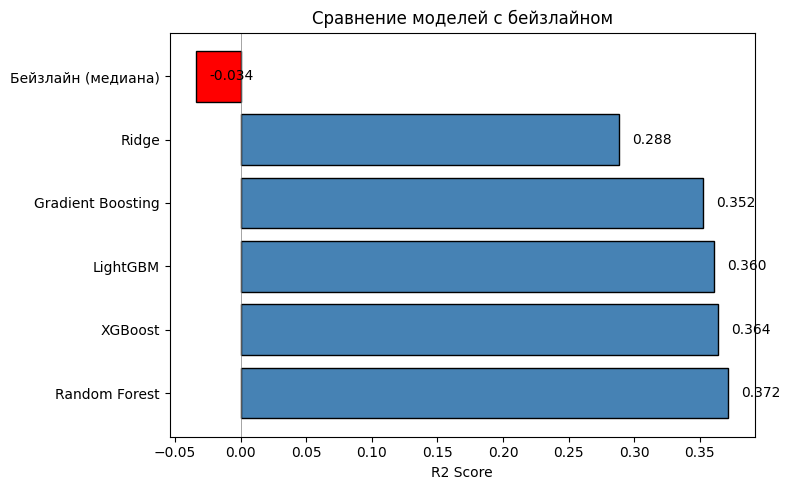

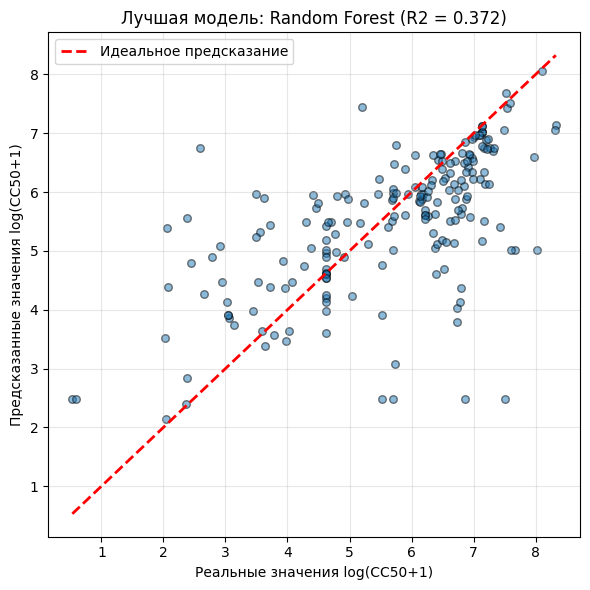


Анализ остатков


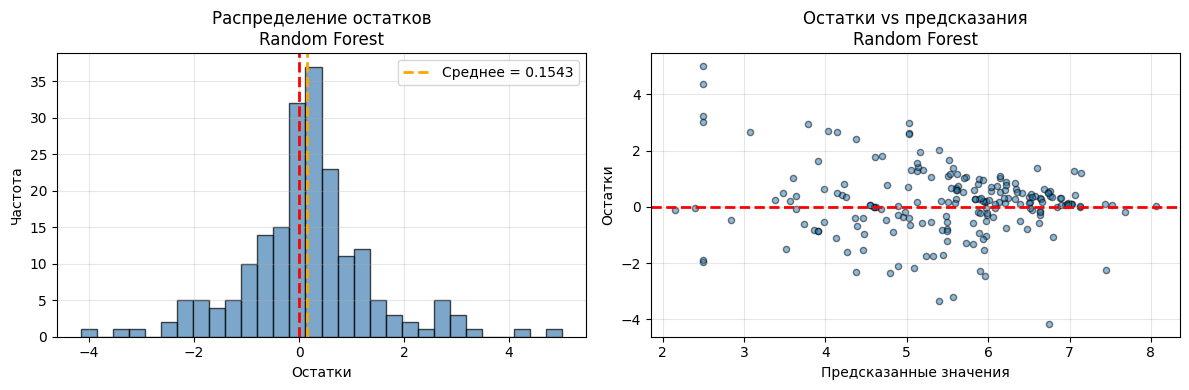

Статистика остатков:
  Среднее: 0.154341 (должно быть около 0)
  Стандартное отклонение: 1.235953
  Медиана: 0.166964
Бейзлайн (медиана) R2 = -0.0339
Регрессия CC50 завершена


In [2]:
# 3: Регрессия CC50

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

print("Регрессия CC50")

# 1. Загрузка данных
df = pd.read_excel('Данные_после_EDA.xlsx')

target_log = 'log_CC50, mM'
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y_log = df[target_log].values

# 2. Очистка от пропусков
mask = ~X.isnull().any(axis=1)
X = X[mask].reset_index(drop=True)
y_log = y_log[mask]

# 3. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Модели и параметры
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'Ridge': Ridge(random_state=42)
}

param_grids = {
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'XGBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'Ridge': {'alpha': [0.1, 1.0, 10.0]}
}

# 5. Обучение и сбор метрик
results = []
print("\nОбучение моделей:")

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    y_pred = grid.best_estimator_.predict(X_test_scaled)
    
    cv_r2 = grid.best_score_
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Модель': name,
        'CV R2': cv_r2,
        'Test R2': test_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Параметры': grid.best_params_
    })
    print(f"  {name}: CV R2 = {cv_r2:.4f}, Test R2 = {test_r2:.4f}")

results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False)

print("\nРезультаты")
print(results_df[['Модель', 'CV R2', 'Test R2', 'Test RMSE']].to_string(index=False))

if len(results_df) > 0:
    best = results_df.iloc[0]
    print(f"\nЛучшая модель: {best['Модель']} (Test R2 = {best['Test R2']:.4f})")
    diff = best['Test R2'] - best['CV R2']
    print(f"Разрыв CV-Test: {diff:.4f} {'(переобучение)' if diff < -0.05 else '(стабильно)'}")

# 6. Визуализация
print("\nВизуализация")

# График 1: Сравнение моделей с бейзлайном
print("\nСравнение с бейзлайном")

dummy = DummyRegressor(strategy='median')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
r2_dummy = r2_score(y_test, y_pred_dummy)

fig, ax = plt.subplots(figsize=(8, 5))
models_all = list(results_df['Модель'].values) + ['Бейзлайн (медиана)']
r2_all = list(results_df['Test R2'].values) + [r2_dummy]
colors_all = ['steelblue'] * len(results_df) + ['red']

bars = ax.barh(models_all, r2_all, color=colors_all, edgecolor='black')
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('R2 Score')
ax.set_title('Сравнение моделей с бейзлайном')
for bar, r2 in zip(bars, r2_all):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{r2:.3f}', va='center')
plt.tight_layout()
plt.show()

# График 2: Предсказание vs Реальность
best_name = results_df.iloc[0]['Модель']
best_params = results_df.iloc[0]['Параметры']

if best_name == 'Ridge':
    best_model = Ridge(**best_params, random_state=42)
else:
    best_model = models[best_name].set_params(**best_params)
    
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k', s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
ax.set_xlabel('Реальные значения log(CC50+1)')
ax.set_ylabel('Предсказанные значения log(CC50+1)')
ax.set_title(f'Лучшая модель: {best_name} (R2 = {results_df.iloc[0]["Test R2"]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Арализ остатков
print("\nАнализ остатков")
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0].axvline(x=residuals.mean(), color='orange', linestyle='--', lw=2, 
                label=f'Среднее = {residuals.mean():.4f}')
axes[0].set_xlabel('Остатки')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Распределение остатков\n{best_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_best, residuals, alpha=0.5, edgecolors='k', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title(f'Остатки vs предсказания\n{best_name}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Статистика остатков:")
print(f"  Среднее: {residuals.mean():.6f} (должно быть около 0)")
print(f"  Стандартное отклонение: {residuals.std():.6f}")
print(f"  Медиана: {np.median(residuals):.6f}")

# 8. Бейзлайн

print(f"Бейзлайн (медиана) R2 = {r2_dummy:.4f}")
print("Регрессия CC50 завершена")

Регрессия CC50 — Итоги

**Лучшая модель:** Random Forest
• Test R² = 0.372 | CV R² = 0.455 | RMSE = 1.246
• Параметры: n_estimators=100, max_depth=10

**Наблюдения:**
1. Качество ниже, чем для IC50 (0.372 vs 0.469) - цитотоксичность сложнее предсказывать
2. Зафиксировано переобучение (разрыв -0.084) → требуется усиление регуляризации
3. Остатки имеют смещение 0.154 → модель систематически недооценивает CC50

**Рекомендации:**\
• Для Random Forest: уменьшить max_depth до 5-7, добавить min_samples_leaf=3\
• Использовать отбор признаков по важности (SelectFromModel)\
• Применить калибровку предсказаний для коррекции смещения

Модель пригодна для предварительного ранжирования соединений по токсичности.